In [39]:
import tensorflow as tf
import numpy as np

print(tf.__version__)
print(np.__version__)
print(tf.config.list_physical_devices())

2.21.0
2.4.4
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [40]:
# =========================
# 1. IMPORTS
# =========================
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import callbacks, layers, models

# Speed-up on GPU when available
if tf.config.list_physical_devices("GPU"):
    tf.keras.mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision enabled")
else:

    print("Running on CPU")

Running on CPU


In [ ]:
# =========================
# 2. LOAD DATASET (RAW SPLIT FOR MULTI-MODEL TRAINING)
# =========================
# Use current working directory (where the notebook is located)
DATASET_PATH = Path.cwd()

# Fallback to absolute path if needed
if not (DATASET_PATH / "black_tea").exists():
    DATASET_PATH = Path(
        r"C:\Users\deept\Fpxnet Dropbox\xafolo xafolo\shareit\course\Deepu\tea project\advanced images"
    )

print(f"Using dataset path: {DATASET_PATH}")

SEED = 123
VAL_SPLIT = 0.2

# Fixed class order requested by user
class_names = [
    "green_tea",
    "black_tea",
    "oolong_tea",
    "chamomile_tea",
    "peppermint_tea",
    "ginger_tea",
    "hibiscus_tea",
    "rooibos_tea",
    "lavender_tea",
    "matcha_tea",
    "chai_tea",
    "turmeric_tea",
    "rosehip_tea",
    "blueberry_tea",
    "raspberry_tea",
    "kukicha_tea",
    "genmaicha_tea",
    "lemon_tea",
]
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

missing_classes = [c for c in class_names if not (DATASET_PATH / c).is_dir()]
if missing_classes:
    raise ValueError(f"Missing class folders: {missing_classes}")

print("Using classes:", class_names)
print("Num classes:", len(class_names))

# Gather all image paths and labels
extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
file_paths = []
labels = []
for cname in class_names:
    class_dir = DATASET_PATH / cname
    class_files = [
        p
        for p in class_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in extensions
    ]
    file_paths.extend([str(p) for p in class_files])
    labels.extend([class_to_idx[cname]] * len(class_files))

file_paths = np.array(file_paths)
labels = np.array(labels, dtype=np.int32)

if len(file_paths) == 0:
    raise ValueError("No images found. Check DATASET_PATH and class folders.")

# Stratified split guarantees class representation in validation set
train_paths, val_paths, train_labels, val_labels = train_test_split(
    file_paths,
    labels,
    test_size=VAL_SPLIT,
    random_state=SEED,
    stratify=labels,
)


def load_raw_image(path, label):
    img_bytes = tf.io.read_file(path)
    img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.cast(img, tf.float32)
    return img, tf.cast(label, tf.int32)


raw_train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
raw_train_ds = raw_train_ds.shuffle(
    len(train_paths), seed=SEED, reshuffle_each_iteration=True
)
raw_train_ds = raw_train_ds.map(load_raw_image, num_parallel_calls=tf.data.AUTOTUNE)

raw_val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
raw_val_ds = raw_val_ds.map(load_raw_image, num_parallel_calls=tf.data.AUTOTUNE)

# Quick sanity check: every class should appear in validation
val_counts = np.bincount(val_labels, minlength=len(class_names))
coverage_df = pd.DataFrame(
    {
        "class": class_names,
        "val_count": val_counts,
    }
)
print("Validation coverage by class:")
display(coverage_df)

Using dataset path: c:\Users\deept\Fpxnet Dropbox\xafolo xafolo\shareit\course\Deepu\tea project\advanced images
Using classes: ['green_tea', 'black_tea', 'oolong_tea', 'chamomile_tea', 'peppermint_tea', 'ginger_tea', 'hibiscus_tea', 'rooibos_tea', 'lavender_tea', 'matcha_tea', 'chai_tea', 'turmeric_tea', 'rosehip_tea', 'blueberry_tea', 'raspberry_tea', 'kukicha_tea', 'genmaicha_tea', 'lemon_tea']
Num classes: 18
Validation coverage by class:


,class,val_count
0,green_tea,60
1,black_tea,60
2,oolong_tea,60
3,chamomile_tea,60
4,peppermint_tea,60
5,ginger_tea,60
6,hibiscus_tea,60
7,rooibos_tea,60
8,lavender_tea,60
9,matcha_tea,60


In [42]:
# =========================
# 3. SAVE CLASS INFO
# =========================
num_classes = len(class_names)
print("Classes:", class_names)

Classes: ['green_tea', 'black_tea', 'oolong_tea', 'chamomile_tea', 'peppermint_tea', 'ginger_tea', 'hibiscus_tea', 'rooibos_tea', 'lavender_tea', 'matcha_tea', 'chai_tea', 'turmeric_tea', 'rosehip_tea', 'blueberry_tea', 'raspberry_tea', 'kukicha_tea', 'genmaicha_tea', 'lemon_tea']


In [43]:
def make_dataset(paths, labels, spec, training=True):
    preprocess_input = resolve_preprocess(spec["resolved_backbone"])

    def preprocess(path, label):
        img_bytes = tf.io.read_file(path)
        img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, spec["img_size"])
        img = tf.cast(img, tf.float32)
        img = preprocess_input(img)
        return img, tf.cast(label, tf.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(
            min(len(paths), 1000), seed=SEED, reshuffle_each_iteration=False
        )
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(spec["batch_size"])
    ds = ds.prefetch(buffer_size=spec["prefetch"])
    return ds

In [44]:
# =========================
# 5. DATA AUGMENTATION
# =========================
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.12),
        layers.RandomZoom(0.15),
        layers.RandomContrast(0.2),
    ]
)

In [ ]:
# =========================
# 4. DEFINE HELPER FUNCTIONS AND TRAIN_ONE_MODEL
# =========================
AUTOTUNE = tf.data.AUTOTUNE


def resolve_preprocess(backbone_name):
    """Get preprocessing function for backbone model."""
    if (
        "EfficientNetV2S" in backbone_name
        or "efficientnet_v2_s" in backbone_name.lower()
    ):
        return tf.keras.applications.efficientnet_v2.preprocess_input
    elif (
        "MobileNetV3Small" in backbone_name
        or "mobilenetv3small" in backbone_name.lower()
    ):
        return tf.keras.applications.mobilenet_v3.preprocess_input
    else:
        return lambda x: x / 255.0


def build_backbone(backbone_name, img_size, num_classes):
    """Build backbone model with the requested input size."""
    if "EfficientNetV2S" in backbone_name:
        backbone = tf.keras.applications.EfficientNetV2S(
            input_shape=(*img_size, 3), include_top=False, weights="imagenet"
        )
    elif "MobileNetV3Small" in backbone_name:
        backbone = tf.keras.applications.MobileNetV3Small(
            input_shape=(*img_size, 3), include_top=False, weights="imagenet"
        )
    else:
        raise ValueError(
            f"Unknown backbone: {backbone_name}. Supported: EfficientNetV2S, MobileNetV3Small"
        )
    return backbone


def train_one_model(spec):
    """Train a single model with the given spec. Uses Functional API to avoid input-shape reuse.

    This ensures each backbone is instantiated with the correct input shape and is
    invoked on an explicit Input tensor rather than being inserted as a pre-built
    Model inside a Sequential container (which can cause input-shape conflicts
    when multiple backbones are used in the same session).
    """
    print(f"\n{'='*60}")
    print(f"Training: {spec['name']}")
    print(f"Backbone: {spec['resolved_backbone']}")
    print(f"Image size: {spec['img_size']}, Batch size: {spec['batch_size']}")
    print(f"{'='*60}")

    # Create datasets
    train_ds = make_dataset(train_paths, train_labels, spec, training=True)
    val_ds = make_dataset(val_paths, val_labels, spec, training=False)

    # Build backbone (fresh instance with correct input shape)
    backbone = build_backbone(spec["resolved_backbone"], spec["img_size"], num_classes)
    backbone.trainable = False

    # Build model using Functional API to ensure shapes align
    inputs = layers.Input(shape=(*spec["img_size"], 3))
    # Create a fresh augmentation block per-model to avoid fixed input_shape conflicts
    local_augmentation = tf.keras.Sequential(
        [
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.12),
            layers.RandomZoom(0.15),
            layers.RandomContrast(0.2),
        ]
    )
    x = local_augmentation(inputs)
    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(spec["dropout"])(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs=inputs, outputs=outputs, name=spec["name"])

    # Callbacks
    save_dir = Path("tea_training_state") / spec["name"]
    save_dir.mkdir(parents=True, exist_ok=True)

    callbacks_list = [
        callbacks.EarlyStopping(
            monitor="val_accuracy", patience=4, restore_best_weights=True
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6
        ),
        callbacks.ModelCheckpoint(
            str(save_dir / "tea_model_best.keras"),
            monitor="val_accuracy",
            save_best_only=True,
        ),
    ]

    # Phase 1: Train head only
    print("\nPhase 1: Training head (backbone frozen)...")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=spec["initial_lr"]),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=spec["epochs_head"],
        callbacks=callbacks_list,
        class_weight=class_weight,
    )

    # Phase 2: Fine-tune
    if spec["epochs_finetune"] > 0:
        print("\nPhase 2: Fine-tuning (unfreezing last layers)...")
        # Unfreeze last N layers of the backbone
        for layer in backbone.layers[-spec["unfreeze_last"] :]:
            layer.trainable = True

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=spec["finetune_lr"]),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"],
        )
        fine_tune_history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=spec["epochs_finetune"],
            callbacks=callbacks_list,
            class_weight=class_weight,
        )
    else:
        fine_tune_history = None

    # Save final model
    final_model_path = save_dir / "tea_model_final.keras"
    model.save(final_model_path)

    # Save state
    state = {
        "best_model_path": str(save_dir / "tea_model_best.keras"),
        "final_model_path": str(final_model_path),
        "model_name": spec["name"],
        "resolved_backbone": spec["resolved_backbone"],
        "img_size": spec["img_size"],
        "batch_size": spec["batch_size"],
        "history": history.history,
        "fine_tune_history": fine_tune_history.history if fine_tune_history else {},
    }

    # Save analysis state
    analysis_state = {
        "class_names": class_names,
        "class_to_idx": class_to_idx,
        "num_classes": num_classes,
        "seed": SEED,
        "val_split": VAL_SPLIT,
        "train_paths": train_paths,
        "val_paths": val_paths,
        "train_labels": train_labels,
        "val_labels": val_labels,
        "img_size": list(spec["img_size"]),
        "batch_size": spec["batch_size"],
        "model_name": spec["name"],
        "backbone": spec["resolved_backbone"],
        "resolved_backbone": spec["resolved_backbone"],
        "requested_backbone": spec["requested_backbone"],
        "history": history.history,
        "fine_tune_history": fine_tune_history.history if fine_tune_history else {},
        "initial_lr": spec["initial_lr"],
        "finetune_lr": spec["finetune_lr"],
        "epochs_head": spec["epochs_head"],
        "epochs_finetune": spec["epochs_finetune"],
        "unfreeze_last": spec["unfreeze_last"],
        "best_model_path": str(save_dir / "tea_model_best.keras"),
        "final_model_path": str(final_model_path),
        "class_counts": class_counts,
        "class_weight": class_weight,
    }

    joblib.dump(analysis_state, save_dir / "analysis_state.joblib", compress=3)

    print(f"\n✓ Training complete for {spec['name']}")
    print(f"  Best model: {state['best_model_path']}")
    print(f"  Final model: {state['final_model_path']}")

    return state

In [46]:
MODEL_SPECS = [
    {
        "name": "efficientnet_v2_s",
        "requested_backbone": "EfficientNetV2S",
        "backbone_candidates": ["EfficientNetV2S"],
        "resolved_backbone": "EfficientNetV2S",
        "img_size": (384, 384),
        "batch_size": 32,
        "dropout": 0.3,
        "prefetch": AUTOTUNE,
        "initial_lr": 1e-3,
        "finetune_lr": 1e-5,
        "epochs_head": 10,
        "epochs_finetune": 5,
        "unfreeze_last": 30,
    },
    {
        "name": "mobilenetv3_small",
        "requested_backbone": "MobileNetV3Small",
        "backbone_candidates": ["MobileNetV3Small"],
        "resolved_backbone": "MobileNetV3Small",
        "img_size": (224, 224),
        "batch_size": 64,
        "dropout": 0.2,
        "prefetch": AUTOTUNE,
        "initial_lr": 1e-3,
        "finetune_lr": 1e-5,
        "epochs_head": 10,
        "epochs_finetune": 5,
        "unfreeze_last": 15,
    },
]

In [47]:
# =========================
# 5. TRAIN BOTH MODELS SEPARATELY
# =========================
run_results = {}
for spec in MODEL_SPECS:
    save_dir = Path("tea_training_state") / spec["name"]
    final_model = save_dir / "tea_model_final.keras"

    # If a final model already exists, load the saved analysis state instead of retraining
    if final_model.exists():
        print(
            f"Found existing trained model for {spec['name']}, loading saved analysis state"
        )
        analysis_path = save_dir / "analysis_state.joblib"
        if analysis_path.exists():
            state = joblib.load(analysis_path)
            # Ensure the state has the expected summary keys
            run_results[spec["name"]] = {
                "best_model_path": state.get(
                    "best_model_path", str(save_dir / "tea_model_best.keras")
                ),
                "final_model_path": state.get("final_model_path", str(final_model)),
                "model_name": spec["name"],
                "resolved_backbone": spec["resolved_backbone"],
                "img_size": spec["img_size"],
                "batch_size": spec["batch_size"],
            }
            print(f"  Loaded saved state for {spec['name']}")
            continue
        else:
            print(f"  analysis_state not found for {spec['name']}, retraining...")

    run_results[spec["name"]] = train_one_model(spec)

print("\nTraining complete for:")
for model_name, state in run_results.items():
    print(
        f"- {model_name}: best={state.get('best_model_path')}, final={state.get('final_model_path')}"
    )

Found existing trained model for efficientnet_v2_s, loading saved analysis state
  Loaded saved state for efficientnet_v2_s
Found existing trained model for mobilenetv3_small, loading saved analysis state
  Loaded saved state for mobilenetv3_small

Training complete for:
- efficientnet_v2_s: best=tea_training_state\efficientnet_v2_s\tea_model_best.keras, final=tea_training_state\efficientnet_v2_s\tea_model_final.keras
- mobilenetv3_small: best=tea_training_state\mobilenetv3_small\tea_model_best.keras, final=tea_training_state\mobilenetv3_small\tea_model_final.keras


In [48]:
# =========================
# 6. RESTORE A SAVED RUN FOR ANALYSIS
# =========================
ANALYSIS_MODEL_NAME = "efficientnet_v2_s"
analysis_state_path = (
    Path("tea_training_state") / ANALYSIS_MODEL_NAME / "analysis_state.joblib"
)

In [49]:
# =========================
# 8.1 SAVE/PERSIST TRAINING RESULTS (After training)
# =========================
# This cell should be run AFTER the training cell completes
# If you're continuing a saved run, run the restore cell first instead

from pathlib import Path
import json
import joblib

# Check if we have training results
if "run_results" not in globals() or not run_results:
    print(
        "ERROR: No training results found. Run the TRAIN BOTH MODELS SEPARATELY cell first."
    )
else:
    # The training was successful - results are already saved by train_one_model()
    print("✓ Training results already saved!")
    print("\nSummary of saved models:")
    for model_name, state in run_results.items():
        print(f"\n  Model: {model_name}")
        print(f"    Best model: {state['best_model_path']}")
        print(f"    Final model: {state['final_model_path']}")

    print(
        "\n✓ Models are ready for analysis. Run the 'RESTORE A SAVED RUN FOR ANALYSIS' cell to load them."
    )

✓ Training results already saved!

Summary of saved models:

  Model: efficientnet_v2_s
    Best model: tea_training_state\efficientnet_v2_s\tea_model_best.keras
    Final model: tea_training_state\efficientnet_v2_s\tea_model_final.keras

  Model: mobilenetv3_small
    Best model: tea_training_state\mobilenetv3_small\tea_model_best.keras
    Final model: tea_training_state\mobilenetv3_small\tea_model_final.keras

✓ Models are ready for analysis. Run the 'RESTORE A SAVED RUN FOR ANALYSIS' cell to load them.


In [50]:
checkpoint_dir = Path("tea_training_state")
checkpoint_dir.mkdir(exist_ok=True)

train_callbacks = [
    callbacks.BackupAndRestore(backup_dir=str(checkpoint_dir / "backup")),
    callbacks.EarlyStopping(
        monitor="val_accuracy", patience=4, restore_best_weights=True
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6
    ),
    callbacks.ModelCheckpoint(
        str(checkpoint_dir / "tea_model_best.keras"),
        monitor="val_accuracy",
        save_best_only=True,
    ),
]

In [51]:
from pathlib import Path
import json

import joblib
import tensorflow as tf

save_dir = Path("tea_training_state")

# Determine which model to load
# Available options: "efficientnet_v2_s", "mobilenetv3_small"
ANALYSIS_MODEL_NAME = "efficientnet_v2_s"
state_path = save_dir / ANALYSIS_MODEL_NAME / "analysis_state.joblib"

if not state_path.exists():
    raise FileNotFoundError(
        f"Missing state bundle: {state_path}\n"
        f"Run the TRAIN BOTH MODELS SEPARATELY cell first to train and save the models.\n"
        f"Available models: efficientnet_v2_s, mobilenetv3_small"
    )

training_state = joblib.load(state_path)

class_names = training_state["class_names"]
class_to_idx = training_state["class_to_idx"]
num_classes = training_state["num_classes"]
IMG_SIZE = tuple(training_state["img_size"])
BATCH_SIZE = training_state["batch_size"]
SEED = training_state["seed"]
VAL_SPLIT = training_state["val_split"]
train_paths = training_state["train_paths"]
val_paths = training_state["val_paths"]
train_labels = training_state["train_labels"]
val_labels = training_state["val_labels"]

# Handle missing class_counts and class_weight (for backward compatibility with old saved states)
if "class_counts" in training_state:
    class_counts = training_state["class_counts"]
    class_weight = training_state["class_weight"]
else:
    # Recompute if not present in saved state
    class_counts = np.bincount(train_labels, minlength=num_classes)
    class_weight = {
        i: len(train_labels) / (num_classes * count)
        for i, count in enumerate(class_counts)
        if count > 0
    }

history = tf.keras.callbacks.History()
history.history = training_state.get("history", {})

fine_tune_history = tf.keras.callbacks.History()
fine_tune_history.history = training_state.get("fine_tune_history", {})

# Rebuild the datasets so training or analysis can continue after reopening.
if "load_and_preprocess" not in globals():

    def load_and_preprocess(path, label):
        img_bytes = tf.io.read_file(path)
        img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32)
        return img, tf.cast(label, tf.int32)


AUTOTUNE = tf.data.AUTOTUNE
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.shuffle(len(train_paths), seed=SEED, reshuffle_each_iteration=True)
train_ds = train_ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).cache().prefetch(buffer_size=AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = val_ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).cache().prefetch(buffer_size=AUTOTUNE)

model_path = training_state["best_model_path"]
if not Path(model_path).exists():
    model_path = training_state["final_model_path"]

model = tf.keras.models.load_model(model_path)

# Extract analysis_state for comparison/export cells
analysis_state = training_state

print("✓ Loaded previous training state")
print(f"  State bundle: {state_path}")
print(f"  Model: {model_path}")
print(f"  Model name: {training_state['model_name']}")

✓ Loaded previous training state
  State bundle: tea_training_state\efficientnet_v2_s\analysis_state.joblib
  Model: tea_training_state\efficientnet_v2_s\tea_model_best.keras
  Model name: efficientnet_v2_s


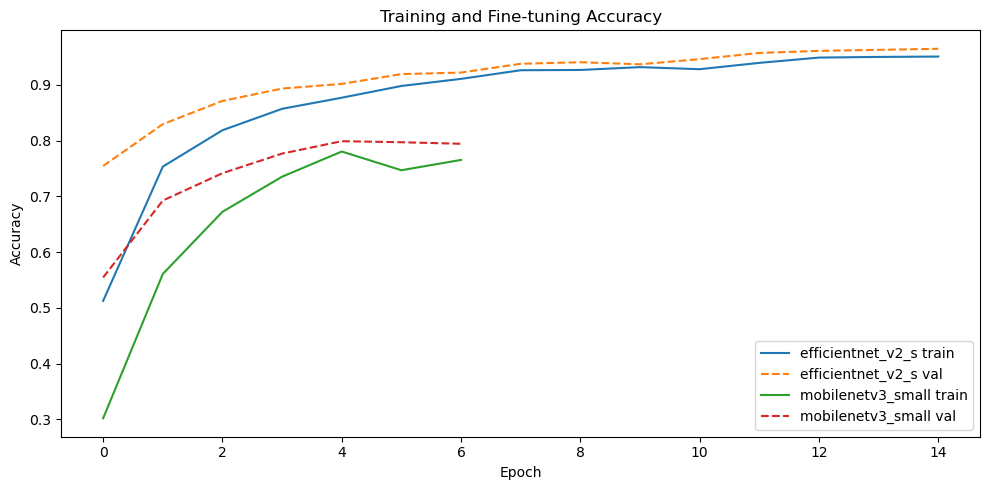

Saved model summary:


,model,best_model_path,final_model_path,final_train_accuracy,final_val_accuracy
0,efficientnet_v2_s,tea_training_state\efficientnet_v2_s\tea_model...,tea_training_state\efficientnet_v2_s\tea_model...,0.9509,0.9648
1,mobilenetv3_small,tea_training_state\mobilenetv3_small\tea_model...,tea_training_state\mobilenetv3_small\tea_model...,0.7655,0.7944


In [52]:
# =========================
# 7. COMPARE SAVED RUNS
# =========================
# First, ensure the training state is loaded
if "analysis_state" not in globals():
    raise NameError(
        "analysis_state is not loaded. Run the 'LOAD TRAINING STATE' cell first."
    )


def load_bundle(model_name):
    bundle_path = Path("tea_training_state") / model_name / "analysis_state.joblib"
    if not bundle_path.exists():
        raise FileNotFoundError(f"Missing saved bundle: {bundle_path}")
    return joblib.load(bundle_path)


bundle_names = [spec["name"] for spec in MODEL_SPECS]
bundle_states = {}
for model_name in bundle_names:
    if model_name == analysis_state["model_name"]:
        bundle_states[model_name] = analysis_state
    else:
        bundle_states[model_name] = load_bundle(model_name)

summary_rows = []
plt.figure(figsize=(10, 5))
for model_name, state in bundle_states.items():
    acc = list(state.get("history", {}).get("accuracy", []))
    val_acc = list(state.get("history", {}).get("val_accuracy", []))
    acc += list(state.get("fine_tune_history", {}).get("accuracy", []))
    val_acc += list(state.get("fine_tune_history", {}).get("val_accuracy", []))

    if acc:
        plt.plot(acc, label=f"{model_name} train")
    if val_acc:
        plt.plot(val_acc, linestyle="--", label=f"{model_name} val")

    summary_rows.append(
        {
            "model": model_name,
            "best_model_path": state["best_model_path"],
            "final_model_path": state["final_model_path"],
            "final_train_accuracy": round(float(acc[-1]), 4) if acc else None,
            "final_val_accuracy": round(float(val_acc[-1]), 4) if val_acc else None,
        }
    )

plt.title("Training and Fine-tuning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

summary_df = pd.DataFrame(summary_rows)
print("Saved model summary:")
display(summary_df)

In [53]:
# =========================
# 8. EXPORT THE ACTIVE ANALYSIS MODEL
# =========================
export_dir = Path("tea_training_state") / analysis_state["model_name"]
export_dir.mkdir(parents=True, exist_ok=True)

# Save in native Keras format (recommended over H5)
active_model_keras = export_dir / f"{analysis_state['model_name']}_export.keras"
model.save(active_model_keras)
print(f"Saved Keras model to: {active_model_keras}")

Saved Keras model to: tea_training_state\efficientnet_v2_s\efficientnet_v2_s_export.keras


In [54]:
# =========================
# 9. CONVERT ACTIVE MODEL TO TFLITE
# =========================
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()
tflite_path = (
    Path("tea_training_state")
    / analysis_state["model_name"]
    / f"{analysis_state['model_name']}.tflite"
)
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print(f"Saved TFLite model to: {tflite_path}")

INFO:tensorflow:Assets written to: C:\Users\deept\AppData\Local\Temp\tmp4da0130g\assets


INFO:tensorflow:Assets written to: C:\Users\deept\AppData\Local\Temp\tmp4da0130g\assets


Saved artifact at 'C:\Users\deept\AppData\Local\Temp\tmp4da0130g'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 384, 384, 3), dtype=tf.float32, name='input_layer_10')
Output Type:
  TensorSpec(shape=(None, 18), dtype=tf.float32, name=None)
Captures:
  2601634715920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2601634715152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2601634714384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2601634711888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2601634711312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2601634712848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2601634716112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2601634711504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2601634710928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2601634713424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  26

Overall validation metrics:


,metric,value
0,accuracy,0.9648
1,precision (macro),0.9652
2,recall (macro),0.9648
3,f1-score (macro),0.9647


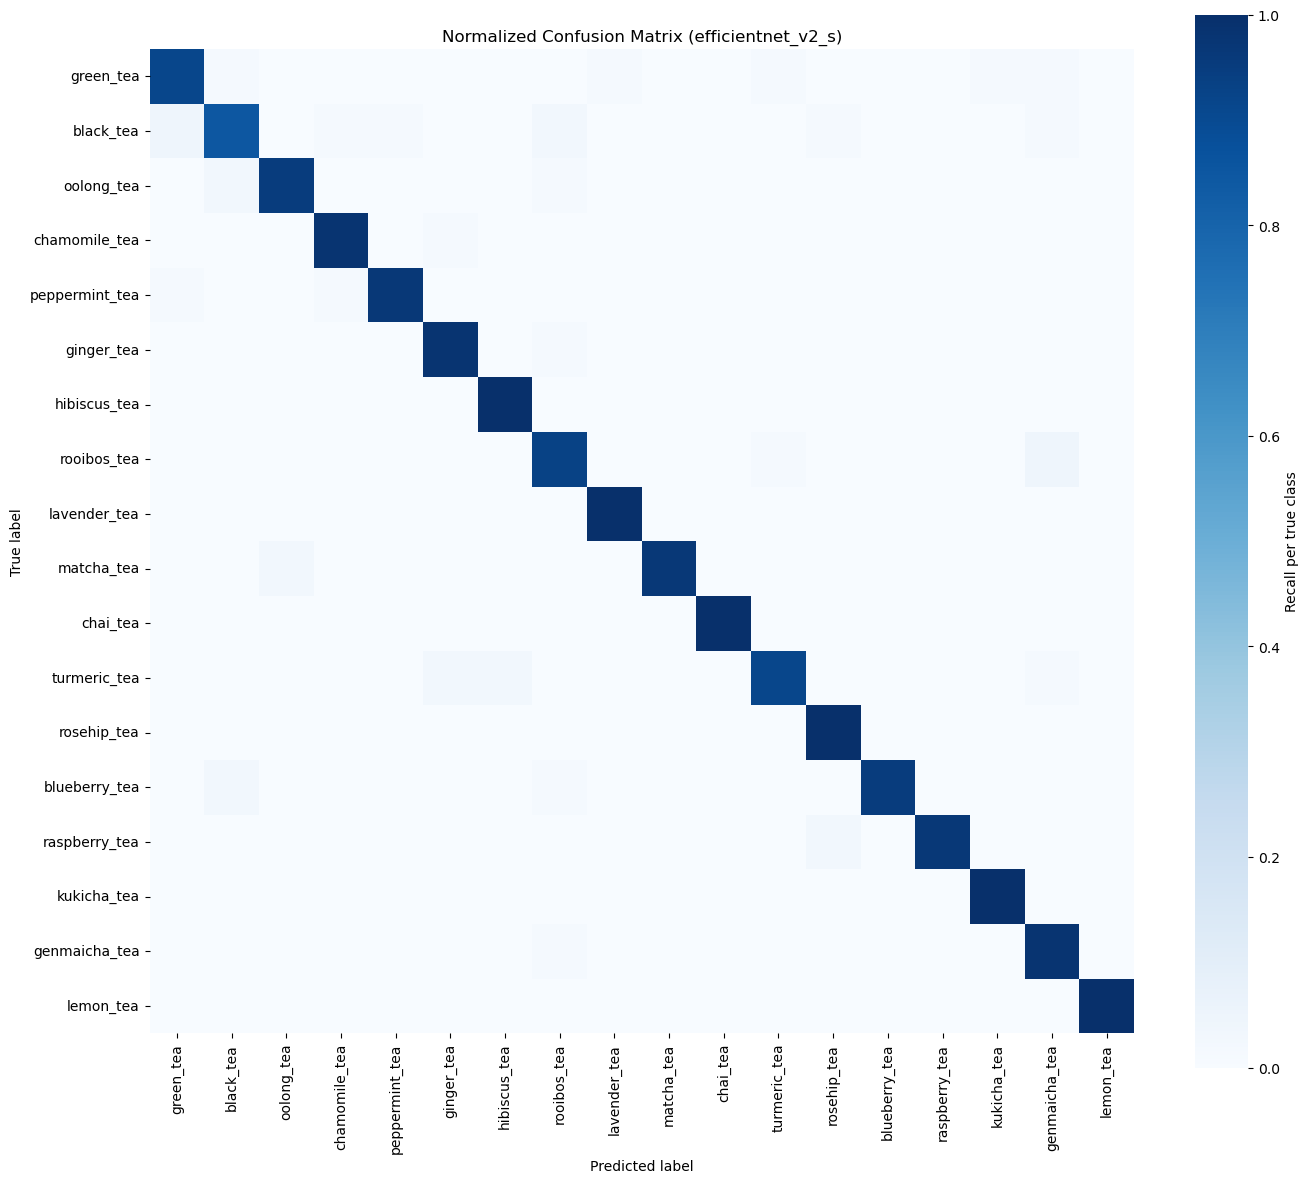

Per-class performance (lowest recall first):


,class,support,recall,most_confused_with,confused_count
1,black_tea,60,0.8500,green_tea,3
0,green_tea,60,0.9167,black_tea,1
11,turmeric_tea,60,0.9167,ginger_tea,2
7,rooibos_tea,60,0.9333,genmaicha_tea,3
13,blueberry_tea,60,0.9500,black_tea,2
2,oolong_tea,60,0.9500,black_tea,2
4,peppermint_tea,60,0.9667,green_tea,1
14,raspberry_tea,60,0.9667,rosehip_tea,2
9,matcha_tea,60,0.9667,oolong_tea,2
3,chamomile_tea,60,0.9833,ginger_tea,1


Top 15 confusion pairs:


,true_class,pred_class,count
5,black_tea,green_tea,3
18,rooibos_tea,genmaicha_tea,3
8,black_tea,rooibos_tea,2
25,raspberry_tea,rosehip_tea,2
19,matcha_tea,oolong_tea,2
21,turmeric_tea,hibiscus_tea,2
23,blueberry_tea,black_tea,2
11,oolong_tea,black_tea,2
20,turmeric_tea,ginger_tea,2
2,green_tea,turmeric_tea,1


In [37]:
# =========================
# 10. CONFUSION MATRIX + TOP CONFUSIONS FOR ACTIVE MODEL
# =========================
# Collect true labels in validation order
active_val_ds = val_ds

y_true = []
for _, labels_batch in active_val_ds:
    y_true.extend(labels_batch.numpy().tolist())
y_true = np.array(y_true, dtype=np.int32)

# Predict classes
y_prob = model.predict(active_val_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

# Confusion matrix
cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=num_classes).numpy()
cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

# Overall validation metrics
sample_count = cm.sum()
accuracy = np.trace(cm) / sample_count if sample_count > 0 else 0.0
precision_per_class = np.divide(
    np.diag(cm),
    cm.sum(axis=0),
    out=np.zeros(num_classes, dtype=float),
    where=cm.sum(axis=0) != 0,
)
recall_per_class = np.divide(
    np.diag(cm),
    cm.sum(axis=1),
    out=np.zeros(num_classes, dtype=float),
    where=cm.sum(axis=1) != 0,
)
f1_per_class = np.divide(
    2 * precision_per_class * recall_per_class,
    precision_per_class + recall_per_class,
    out=np.zeros(num_classes, dtype=float),
    where=(precision_per_class + recall_per_class) != 0,
)

metrics_df = pd.DataFrame(
    [
        {"metric": "accuracy", "value": round(float(accuracy), 4)},
        {
            "metric": "precision (macro)",
            "value": round(float(precision_per_class.mean()), 4),
        },
        {"metric": "recall (macro)", "value": round(float(recall_per_class.mean()), 4)},
        {"metric": "f1-score (macro)", "value": round(float(f1_per_class.mean()), 4)},
    ]
)

print("Overall validation metrics:")
display(metrics_df)

# Plot normalized confusion matrix
plt.figure(figsize=(14, 12))
sns.heatmap(
    cm_norm,
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues",
    vmin=0,
    vmax=1,
    square=True,
    cbar_kws={"label": "Recall per true class"},
)
plt.title(f"Normalized Confusion Matrix ({analysis_state['model_name']})")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Per-class recall and strongest confusion target
rows = []
for i, true_name in enumerate(class_names):
    total = int(cm[i].sum())
    correct = int(cm[i, i])
    recall = (correct / total) if total > 0 else 0.0

    row_wo_diag = cm[i].copy()
    row_wo_diag[i] = 0
    worst_j = int(np.argmax(row_wo_diag))
    worst_count = int(row_wo_diag[worst_j])

    rows.append(
        {
            "class": true_name,
            "support": total,
            "recall": round(recall, 4),
            "most_confused_with": class_names[worst_j],
            "confused_count": worst_count,
        }
    )

per_class_df = pd.DataFrame(rows).sort_values(by="recall")
print("Per-class performance (lowest recall first):")
display(per_class_df)

# Global top confusion pairs (excluding diagonal)
pairs = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i, j] > 0:
            pairs.append((class_names[i], class_names[j], int(cm[i, j])))

pairs_df = pd.DataFrame(pairs, columns=["true_class", "pred_class", "count"])
pairs_df = pairs_df.sort_values(by="count", ascending=False).head(15)

print("Top 15 confusion pairs:")
display(pairs_df)

In [59]:
# Enhanced confusion matrix renderer with per-class annotations (high-res)


def plot_confusion_annotated(
    cm_norm,
    cm_raw,
    class_names,
    model_name,
    precisions,
    recalls,
    f1_scores,
    out_path=None,
):
    """Plot confusion matrix with annotations and per-class metrics."""
    import math

    n = len(class_names)
    # High-res figure (300 DPI)
    fig, ax = plt.subplots(figsize=(16, 14), dpi=100)  # Will save at 300 DPI

    # Use imshow for fast rendering
    im = ax.imshow(
        cm_norm, cmap="Blues", vmin=0, vmax=1, interpolation="nearest", rasterized=True
    )

    # Reduce tick labels if too many
    max_tick_labels = 20
    if n > max_tick_labels:
        step = math.ceil(n / max_tick_labels)
        xticks = np.arange(0, n, step)
        yticks = np.arange(0, n, step)
        ax.set_xticks(xticks)
        ax.set_yticks(yticks)
        ax.set_xticklabels([class_names[i] for i in xticks], rotation=90, fontsize=9)
        ax.set_yticklabels([class_names[i] for i in yticks], fontsize=9)
    else:
        ax.set_xticks(np.arange(n))
        ax.set_yticks(np.arange(n))
        ax.set_xticklabels(class_names, rotation=90, fontsize=9)
        ax.set_yticklabels(class_names, fontsize=9)

    # Add count annotations in cells
    for i in range(n):
        for j in range(n):
            count = cm_raw[i, j]
            normalized = cm_norm[i, j]
            text_color = "white" if cm_norm[i, j] > 0.5 else "black"
            ax.text(
                j,
                i,
                f"{count}\n({normalized:.2f})",
                ha="center",
                va="center",
                color=text_color,
                fontsize=6,
            )

    ax.set_xlabel("Predicted Label", fontsize=12, fontweight="bold")
    ax.set_ylabel("True Label", fontsize=12, fontweight="bold")
    ax.set_title(
        f"Confusion Matrix with Annotations: {model_name}",
        fontsize=14,
        fontweight="bold",
        pad=20,
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Recall per True Class", fontsize=11)

    # Add per-class metrics text box
    metrics_text = "Per-Class F1 Scores (Top/Bottom 3):\n"
    f1_indices = np.argsort(f1_scores)[::-1]
    for idx in f1_indices[:3]:
        metrics_text += f"{class_names[idx]}: {f1_scores[idx]:.3f}\n"
    metrics_text += "...\n"
    for idx in f1_indices[-3:]:
        metrics_text += f"{class_names[idx]}: {f1_scores[idx]:.3f}\n"

    ax.text(
        0.98,
        0.02,
        metrics_text,
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment="bottom",
        horizontalalignment="right",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
    )

    plt.tight_layout()
    if out_path:
        fig.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
        plt.close(fig)
        print(f"Saved high-res confusion matrix to: {out_path}")
    else:
        plt.show()


# Usage: plot single model confusion matrix with annotations
if "cm_norm" in globals() and "analysis_state" in globals():
    out_file = Path(f"confusion_matrix_annotated_{analysis_state['model_name']}.png")
    plot_confusion_annotated(
        cm_norm,
        cm,
        class_names,
        analysis_state["model_name"],
        precision_per_class,
        recall_per_class,
        f1_per_class,
        out_path=out_file,
    )
else:
    print("cm_norm or analysis_state not found — run the prediction/CM cell first.")

Saved high-res confusion matrix to: confusion_matrix_annotated_efficientnet_v2_s.png


In [56]:
# =========================
# 11. LOAD & EVALUATE BOTH MODELS FOR COMPARISON
# =========================
from pathlib import Path
import joblib
import tensorflow as tf

# Define model names
model_names = ["efficientnet_v2_s", "mobilenetv3_small"]
model_results = {}

for model_name in model_names:
    print(f"\n{'='*60}")
    print(f"Loading and evaluating: {model_name}")
    print(f"{'='*60}")

    # Load saved state
    state_path = Path("tea_training_state") / model_name / "analysis_state.joblib"
    if not state_path.exists():
        print(f"⚠️  State not found for {model_name}. Skipping...")
        continue

    saved_state = joblib.load(state_path)

    # Load best model
    model_path = saved_state["best_model_path"]
    if not Path(model_path).exists():
        model_path = saved_state["final_model_path"]

    model = tf.keras.models.load_model(model_path)

    # Prepare validation dataset
    analysis_spec = {
        "resolved_backbone": saved_state["resolved_backbone"],
        "img_size": tuple(saved_state["img_size"]),
        "batch_size": saved_state["batch_size"],
        "prefetch": tf.data.AUTOTUNE,
    }

    val_ds = make_dataset(val_paths, val_labels, analysis_spec, training=False)

    # Get predictions
    y_true_list = []
    for _, labels_batch in val_ds:
        y_true_list.extend(labels_batch.numpy().tolist())
    y_true_model = np.array(y_true_list, dtype=np.int32)

    y_prob_model = model.predict(val_ds, verbose=0)
    y_pred_model = np.argmax(y_prob_model, axis=1)

    # Compute confusion matrix
    cm_model = tf.math.confusion_matrix(
        y_true_model, y_pred_model, num_classes=num_classes
    ).numpy()
    cm_norm_model = cm_model / np.maximum(cm_model.sum(axis=1, keepdims=True), 1)

    # Compute metrics
    sample_count_model = cm_model.sum()
    accuracy_model = (
        np.trace(cm_model) / sample_count_model if sample_count_model > 0 else 0.0
    )

    precision_per_class_model = np.divide(
        np.diag(cm_model),
        cm_model.sum(axis=0),
        out=np.zeros(num_classes, dtype=float),
        where=cm_model.sum(axis=0) != 0,
    )

    recall_per_class_model = np.divide(
        np.diag(cm_model),
        cm_model.sum(axis=1),
        out=np.zeros(num_classes, dtype=float),
        where=cm_model.sum(axis=1) != 0,
    )

    f1_per_class_model = np.divide(
        2 * precision_per_class_model * recall_per_class_model,
        precision_per_class_model + recall_per_class_model,
        out=np.zeros(num_classes, dtype=float),
        where=(precision_per_class_model + recall_per_class_model) != 0,
    )

    # Store results
    model_results[model_name] = {
        "model": model,
        "saved_state": saved_state,
        "y_true": y_true_model,
        "y_pred": y_pred_model,
        "y_prob": y_prob_model,
        "cm": cm_model,
        "cm_norm": cm_norm_model,
        "accuracy": accuracy_model,
        "precision": precision_per_class_model,
        "recall": recall_per_class_model,
        "f1": f1_per_class_model,
    }

    print(f"✓ Loaded and evaluated {model_name}")
    print(f"  Accuracy: {accuracy_model:.4f}")
    print(f"  Macro F1-Score: {f1_per_class_model.mean():.4f}")


Loading and evaluating: efficientnet_v2_s
✓ Loaded and evaluated efficientnet_v2_s
  Accuracy: 0.9648
  Macro F1-Score: 0.9647

Loading and evaluating: mobilenetv3_small
✓ Loaded and evaluated mobilenetv3_small
  Accuracy: 0.7991
  Macro F1-Score: 0.7980


In [57]:
# =========================
# 12. MODEL COMPARISON TABLE - ACCURACY, PRECISION, RECALL, F1
# =========================
print("\n" + "=" * 80)
print("COMPREHENSIVE MODEL COMPARISON TABLE")
print("=" * 80 + "\n")

# Create comparison dataframe
comparison_data = []
for model_name, results in model_results.items():
    comparison_data.append(
        {
            "Model": model_name,
            "Accuracy": f"{results['accuracy']:.4f}",
            "Macro Precision": f"{results['precision'].mean():.4f}",
            "Macro Recall": f"{results['recall'].mean():.4f}",
            "Macro F1-Score": f"{results['f1'].mean():.4f}",
            "Min Precision": f"{results['precision'].min():.4f}",
            "Max Precision": f"{results['precision'].max():.4f}",
            "Min Recall": f"{results['recall'].min():.4f}",
            "Max Recall": f"{results['recall'].max():.4f}",
            "Min F1": f"{results['f1'].min():.4f}",
            "Max F1": f"{results['f1'].max():.4f}",
        }
    )

comparison_df = pd.DataFrame(comparison_data)
print("Overall Performance Metrics:")
display(comparison_df)

# Detailed per-class comparison
print("\n\nDetailed Per-Class Metrics Comparison:\n")

for model_name, results in model_results.items():
    print(f"\n{'='*80}")
    print(f"{model_name.upper()}: PER-CLASS METRICS")
    print(f"{'='*80}")

    per_class_metrics = pd.DataFrame(
        {
            "Class": class_names,
            "Precision": [f"{p:.4f}" for p in results["precision"]],
            "Recall": [f"{r:.4f}" for r in results["recall"]],
            "F1-Score": [f"{f1:.4f}" for f1 in results["f1"]],
        }
    )
    display(per_class_metrics)

# Side-by-side comparison
print("\n\nDirect Comparison (EfficientNetV2S vs MobileNetV3Small):\n")

if len(model_results) == 2:
    model_list = list(model_results.keys())
    results1 = model_results[model_list[0]]
    results2 = model_results[model_list[1]]

    side_by_side = pd.DataFrame(
        {
            "Class": class_names,
            f"{model_list[0]}_Precision": [f"{p:.4f}" for p in results1["precision"]],
            f"{model_list[1]}_Precision": [f"{p:.4f}" for p in results2["precision"]],
            f"{model_list[0]}_Recall": [f"{r:.4f}" for r in results1["recall"]],
            f"{model_list[1]}_Recall": [f"{r:.4f}" for r in results2["recall"]],
            f"{model_list[0]}_F1": [f"{f1:.4f}" for f1 in results1["f1"]],
            f"{model_list[1]}_F1": [f"{f1:.4f}" for f1 in results2["f1"]],
        }
    )
    display(side_by_side)

print("\n✓ Comparison table complete\n")


COMPREHENSIVE MODEL COMPARISON TABLE

Overall Performance Metrics:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1-Score,Min Precision,Max Precision,Min Recall,Max Recall,Min F1,Max F1
0,efficientnet_v2_s,0.9648,0.9652,0.9648,0.9647,0.9032,1.0000,0.8500,1.0000,0.8793,1.0000
1,mobilenetv3_small,0.7991,0.8103,0.7991,0.7980,0.5875,0.9464,0.5833,0.9833,0.6714,0.9180




Detailed Per-Class Metrics Comparison:


EFFICIENTNET_V2_S: PER-CLASS METRICS


,Class,Precision,Recall,F1-Score
0,green_tea,0.9322,0.9167,0.9244
1,black_tea,0.9107,0.8500,0.8793
2,oolong_tea,0.9661,0.9500,0.9580
3,chamomile_tea,0.9672,0.9833,0.9752
4,peppermint_tea,0.9831,0.9667,0.9748
5,ginger_tea,0.9516,0.9833,0.9672
6,hibiscus_tea,0.9677,1.0000,0.9836
7,rooibos_tea,0.9032,0.9333,0.9180
8,lavender_tea,0.9836,1.0000,0.9917
9,matcha_tea,1.0000,0.9667,0.9831



MOBILENETV3_SMALL: PER-CLASS METRICS


,Class,Precision,Recall,F1-Score
0,green_tea,0.7400,0.6167,0.6727
1,black_tea,0.7818,0.7167,0.7478
2,oolong_tea,0.8163,0.6667,0.7339
3,chamomile_tea,0.8065,0.8333,0.8197
4,peppermint_tea,0.6613,0.6833,0.6721
5,ginger_tea,0.8000,0.7333,0.7652
6,hibiscus_tea,0.9464,0.8833,0.9138
7,rooibos_tea,0.5875,0.7833,0.6714
8,lavender_tea,0.8429,0.9833,0.9077
9,matcha_tea,0.9167,0.9167,0.9167




Direct Comparison (EfficientNetV2S vs MobileNetV3Small):



,Class,efficientnet_v2_s_Precision,mobilenetv3_small_Precision,efficientnet_v2_s_Recall,mobilenetv3_small_Recall,efficientnet_v2_s_F1,mobilenetv3_small_F1
0,green_tea,0.9322,0.7400,0.9167,0.6167,0.9244,0.6727
1,black_tea,0.9107,0.7818,0.8500,0.7167,0.8793,0.7478
2,oolong_tea,0.9661,0.8163,0.9500,0.6667,0.9580,0.7339
3,chamomile_tea,0.9672,0.8065,0.9833,0.8333,0.9752,0.8197
4,peppermint_tea,0.9831,0.6613,0.9667,0.6833,0.9748,0.6721
5,ginger_tea,0.9516,0.8000,0.9833,0.7333,0.9672,0.7652
6,hibiscus_tea,0.9677,0.9464,1.0000,0.8833,0.9836,0.9138
7,rooibos_tea,0.9032,0.5875,0.9333,0.7833,0.9180,0.6714
8,lavender_tea,0.9836,0.8429,1.0000,0.9833,0.9917,0.9077
9,matcha_tea,1.0000,0.9167,0.9667,0.9167,0.9831,0.9167



✓ Comparison table complete



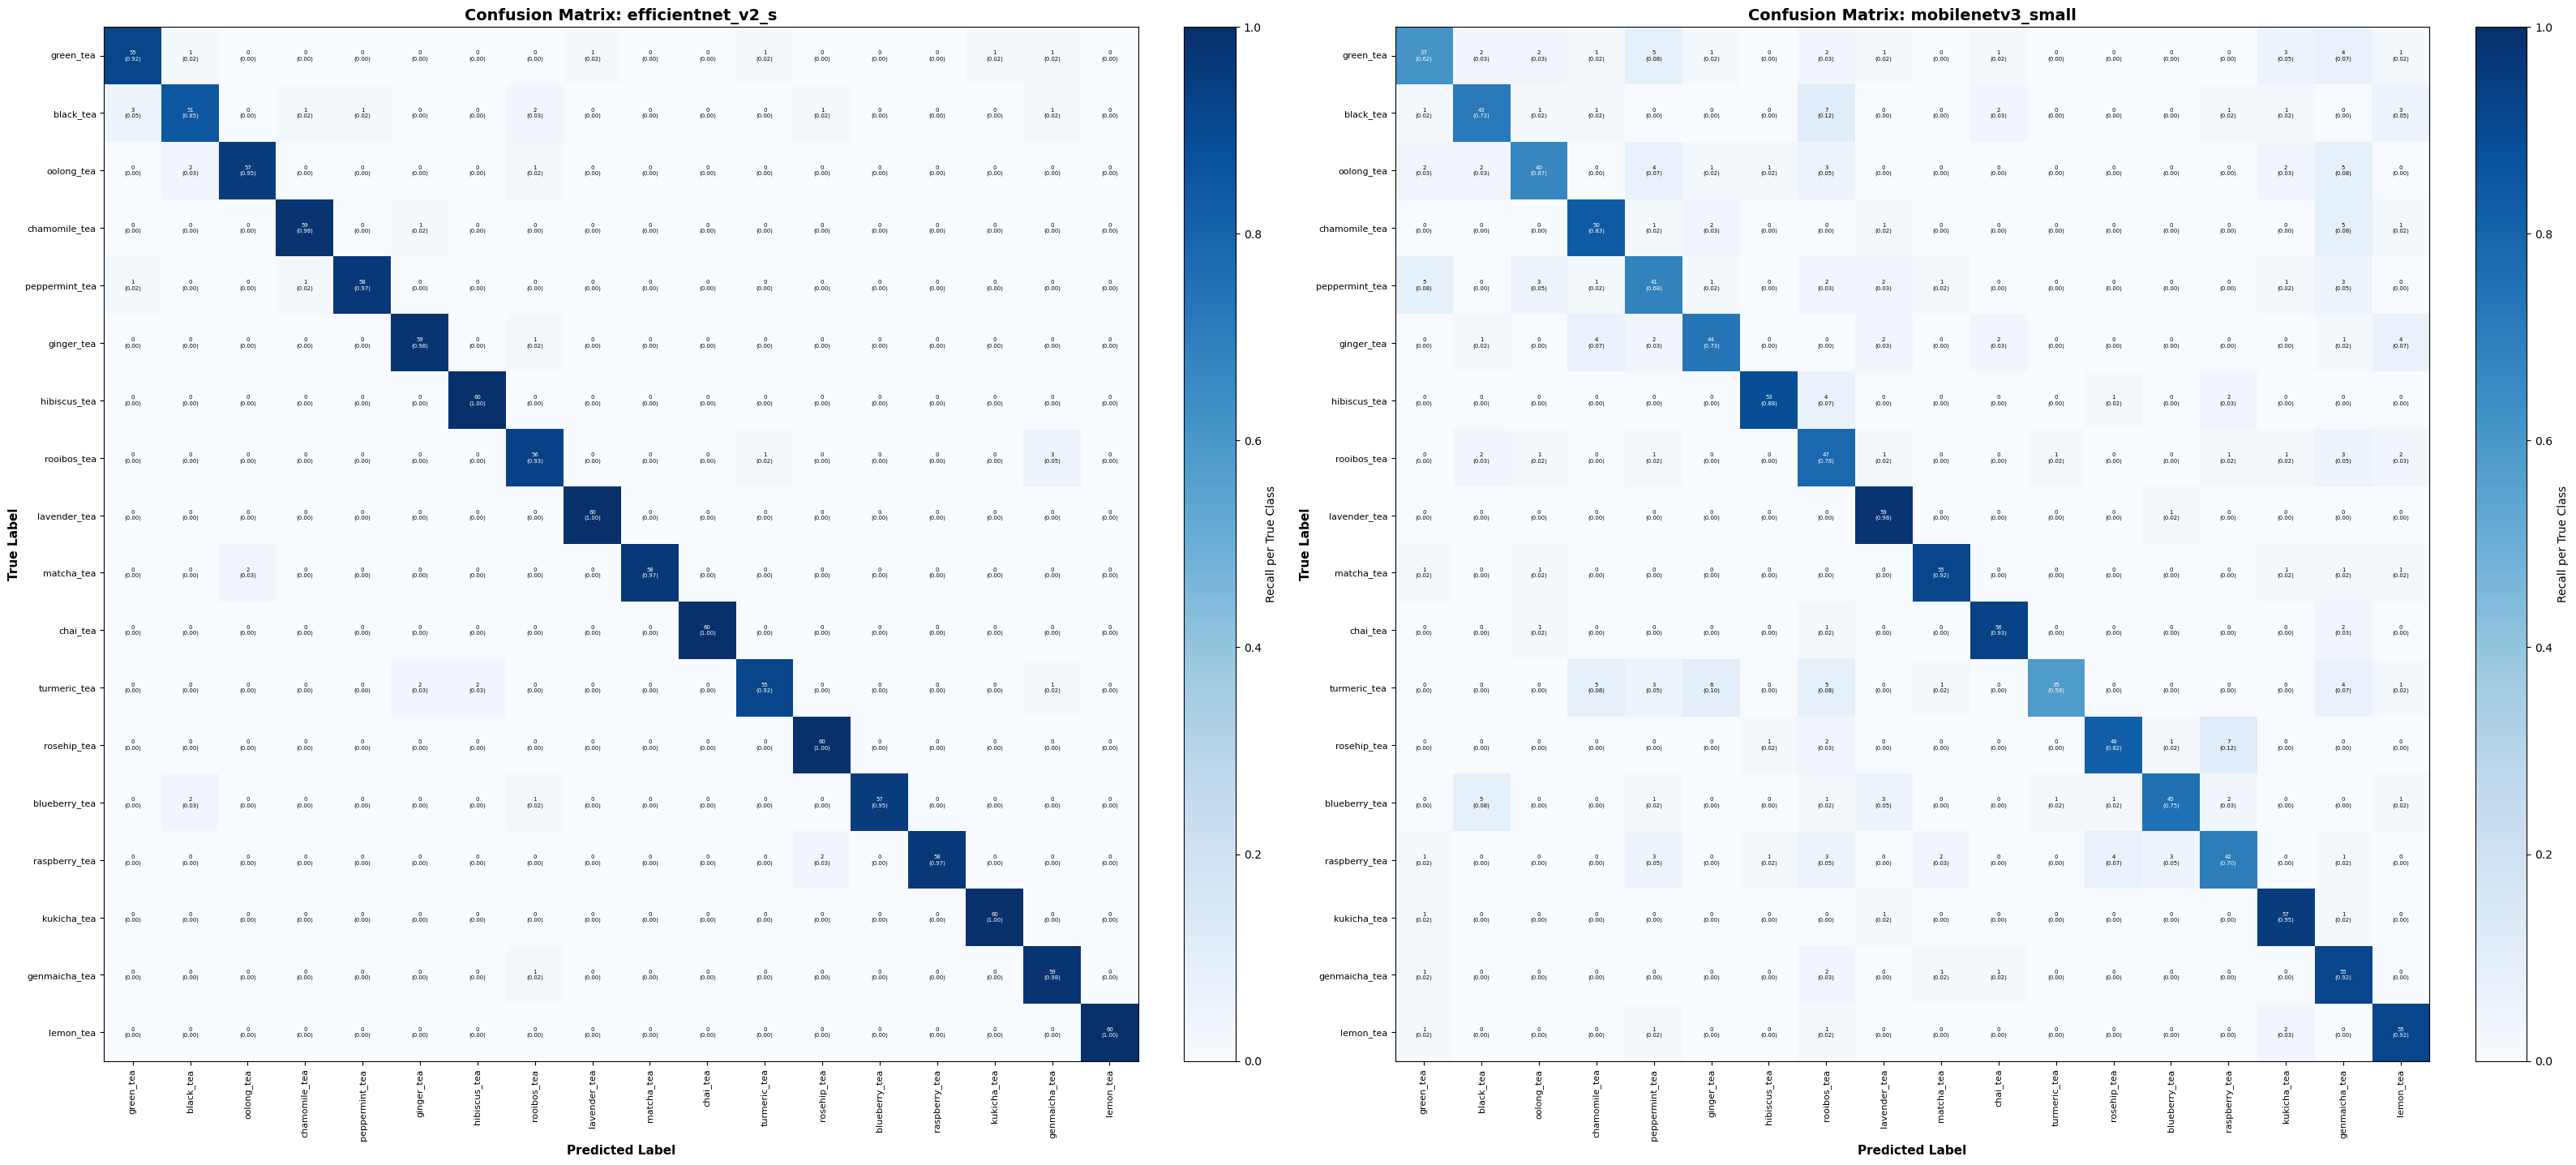

✓ High-res side-by-side confusion matrices saved and displayed



In [60]:
# =========================
# 13. SIDE-BY-SIDE CONFUSION MATRICES (HIGH-RES WITH ANNOTATIONS)
# =========================
if len(model_results) == 2:
    model_list = list(model_results.keys())
    import math

    fig, axes = plt.subplots(1, 2, figsize=(32, 14))

    for idx, model_name in enumerate(model_list):
        results = model_results[model_name]
        cm_norm = results["cm_norm"]
        cm_raw = results["cm"]
        precisions = results["precision"]
        recalls = results["recall"]
        f1s = results["f1"]

        n = len(class_names)
        im = axes[idx].imshow(
            cm_norm,
            cmap="Blues",
            vmin=0,
            vmax=1,
            interpolation="nearest",
            rasterized=True,
        )

        # Set ticks (reduce if too many)
        max_tick_labels = 20
        if n > max_tick_labels:
            step = math.ceil(n / max_tick_labels)
            xticks = np.arange(0, n, step)
            yticks = np.arange(0, n, step)
            axes[idx].set_xticks(xticks)
            axes[idx].set_yticks(yticks)
            axes[idx].set_xticklabels(
                [class_names[i] for i in xticks], rotation=90, fontsize=8
            )
            axes[idx].set_yticklabels([class_names[i] for i in yticks], fontsize=8)
        else:
            axes[idx].set_xticks(np.arange(n))
            axes[idx].set_yticks(np.arange(n))
            axes[idx].set_xticklabels(class_names, rotation=90, fontsize=8)
            axes[idx].set_yticklabels(class_names, fontsize=8)

        # Add count annotations
        for i in range(n):
            for j in range(n):
                count = cm_raw[i, j]
                norm_val = cm_norm[i, j]
                text_color = "white" if norm_val > 0.5 else "black"
                axes[idx].text(
                    j,
                    i,
                    f"{count}\n({norm_val:.2f})",
                    ha="center",
                    va="center",
                    color=text_color,
                    fontsize=5,
                )

        axes[idx].set_title(
            f"Confusion Matrix: {model_name}", fontsize=14, fontweight="bold"
        )
        axes[idx].set_xlabel("Predicted Label", fontsize=11, fontweight="bold")
        axes[idx].set_ylabel("True Label", fontsize=11, fontweight="bold")

        cbar = fig.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)
        cbar.set_label("Recall per True Class", fontsize=10)

    plt.tight_layout()
    plt.savefig(
        Path("confusion_matrices_sidebyside_highres.png"),
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )
    plt.show()
    print(f"✓ High-res side-by-side confusion matrices saved and displayed\n")

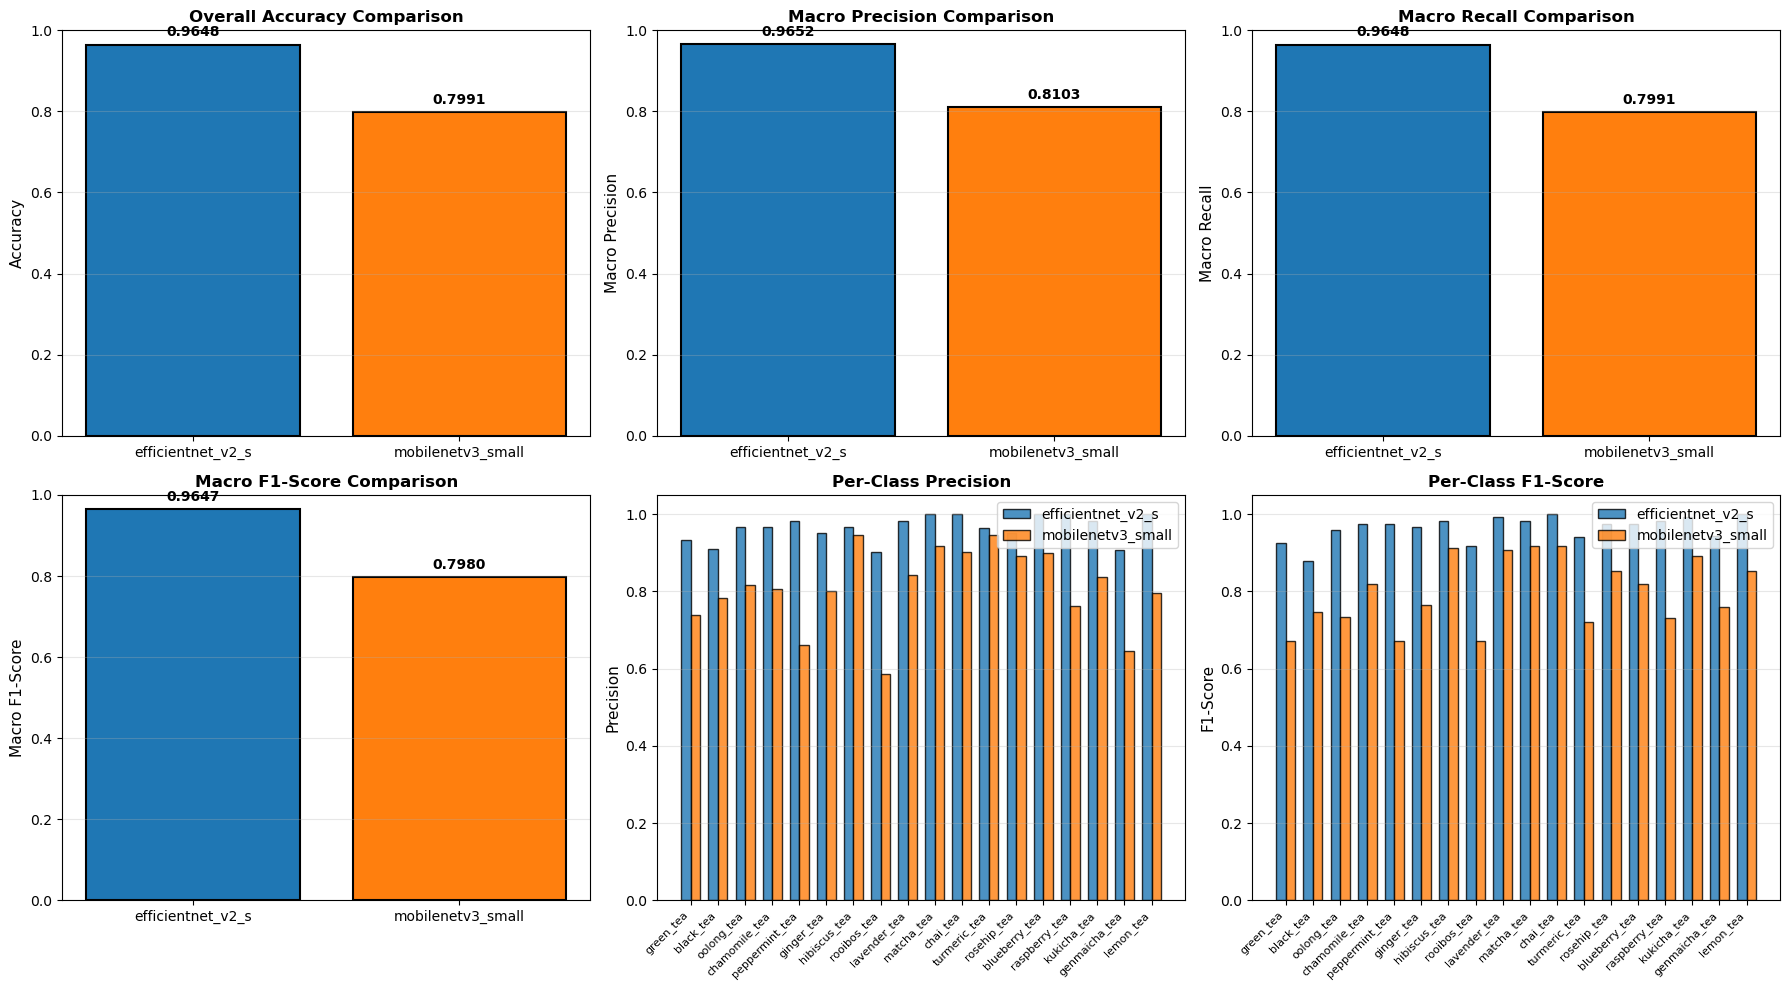

✓ Performance comparison visualizations displayed



In [61]:
# =========================
# 14. PERFORMANCE COMPARISON VISUALIZATIONS
# =========================
if len(model_results) == 2:
    model_list = list(model_results.keys())

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # 1. Overall Accuracy Comparison
    accuracies = [model_results[m]["accuracy"] for m in model_list]
    colors = ["#1f77b4", "#ff7f0e"]
    axes[0, 0].bar(
        model_list, accuracies, color=colors, edgecolor="black", linewidth=1.5
    )
    axes[0, 0].set_ylabel("Accuracy", fontsize=11)
    axes[0, 0].set_title("Overall Accuracy Comparison", fontsize=12, fontweight="bold")
    axes[0, 0].set_ylim([0, 1])
    for i, v in enumerate(accuracies):
        axes[0, 0].text(
            i, v + 0.02, f"{v:.4f}", ha="center", fontsize=10, fontweight="bold"
        )
    axes[0, 0].grid(axis="y", alpha=0.3)

    # 2. Macro Precision Comparison
    precisions = [model_results[m]["precision"].mean() for m in model_list]
    axes[0, 1].bar(
        model_list, precisions, color=colors, edgecolor="black", linewidth=1.5
    )
    axes[0, 1].set_ylabel("Macro Precision", fontsize=11)
    axes[0, 1].set_title("Macro Precision Comparison", fontsize=12, fontweight="bold")
    axes[0, 1].set_ylim([0, 1])
    for i, v in enumerate(precisions):
        axes[0, 1].text(
            i, v + 0.02, f"{v:.4f}", ha="center", fontsize=10, fontweight="bold"
        )
    axes[0, 1].grid(axis="y", alpha=0.3)

    # 3. Macro Recall Comparison
    recalls = [model_results[m]["recall"].mean() for m in model_list]
    axes[0, 2].bar(model_list, recalls, color=colors, edgecolor="black", linewidth=1.5)
    axes[0, 2].set_ylabel("Macro Recall", fontsize=11)
    axes[0, 2].set_title("Macro Recall Comparison", fontsize=12, fontweight="bold")
    axes[0, 2].set_ylim([0, 1])
    for i, v in enumerate(recalls):
        axes[0, 2].text(
            i, v + 0.02, f"{v:.4f}", ha="center", fontsize=10, fontweight="bold"
        )
    axes[0, 2].grid(axis="y", alpha=0.3)

    # 4. Macro F1-Score Comparison
    f1_scores = [model_results[m]["f1"].mean() for m in model_list]
    axes[1, 0].bar(
        model_list, f1_scores, color=colors, edgecolor="black", linewidth=1.5
    )
    axes[1, 0].set_ylabel("Macro F1-Score", fontsize=11)
    axes[1, 0].set_title("Macro F1-Score Comparison", fontsize=12, fontweight="bold")
    axes[1, 0].set_ylim([0, 1])
    for i, v in enumerate(f1_scores):
        axes[1, 0].text(
            i, v + 0.02, f"{v:.4f}", ha="center", fontsize=10, fontweight="bold"
        )
    axes[1, 0].grid(axis="y", alpha=0.3)

    # 5. Per-Class Precision Comparison
    results1 = model_results[model_list[0]]
    results2 = model_results[model_list[1]]

    x_pos = np.arange(len(class_names))
    width = 0.35

    axes[1, 1].bar(
        x_pos - width / 2,
        results1["precision"],
        width,
        label=model_list[0],
        alpha=0.8,
        color="#1f77b4",
        edgecolor="black",
    )
    axes[1, 1].bar(
        x_pos + width / 2,
        results2["precision"],
        width,
        label=model_list[1],
        alpha=0.8,
        color="#ff7f0e",
        edgecolor="black",
    )
    axes[1, 1].set_ylabel("Precision", fontsize=11)
    axes[1, 1].set_title("Per-Class Precision", fontsize=12, fontweight="bold")
    axes[1, 1].set_xticks(x_pos)
    axes[1, 1].set_xticklabels(class_names, rotation=45, ha="right", fontsize=8)
    axes[1, 1].legend()
    axes[1, 1].grid(axis="y", alpha=0.3)

    # 6. Per-Class F1-Score Comparison
    axes[1, 2].bar(
        x_pos - width / 2,
        results1["f1"],
        width,
        label=model_list[0],
        alpha=0.8,
        color="#1f77b4",
        edgecolor="black",
    )
    axes[1, 2].bar(
        x_pos + width / 2,
        results2["f1"],
        width,
        label=model_list[1],
        alpha=0.8,
        color="#ff7f0e",
        edgecolor="black",
    )
    axes[1, 2].set_ylabel("F1-Score", fontsize=11)
    axes[1, 2].set_title("Per-Class F1-Score", fontsize=12, fontweight="bold")
    axes[1, 2].set_xticks(x_pos)
    axes[1, 2].set_xticklabels(class_names, rotation=45, ha="right", fontsize=8)
    axes[1, 2].legend()
    axes[1, 2].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("✓ Performance comparison visualizations displayed\n")

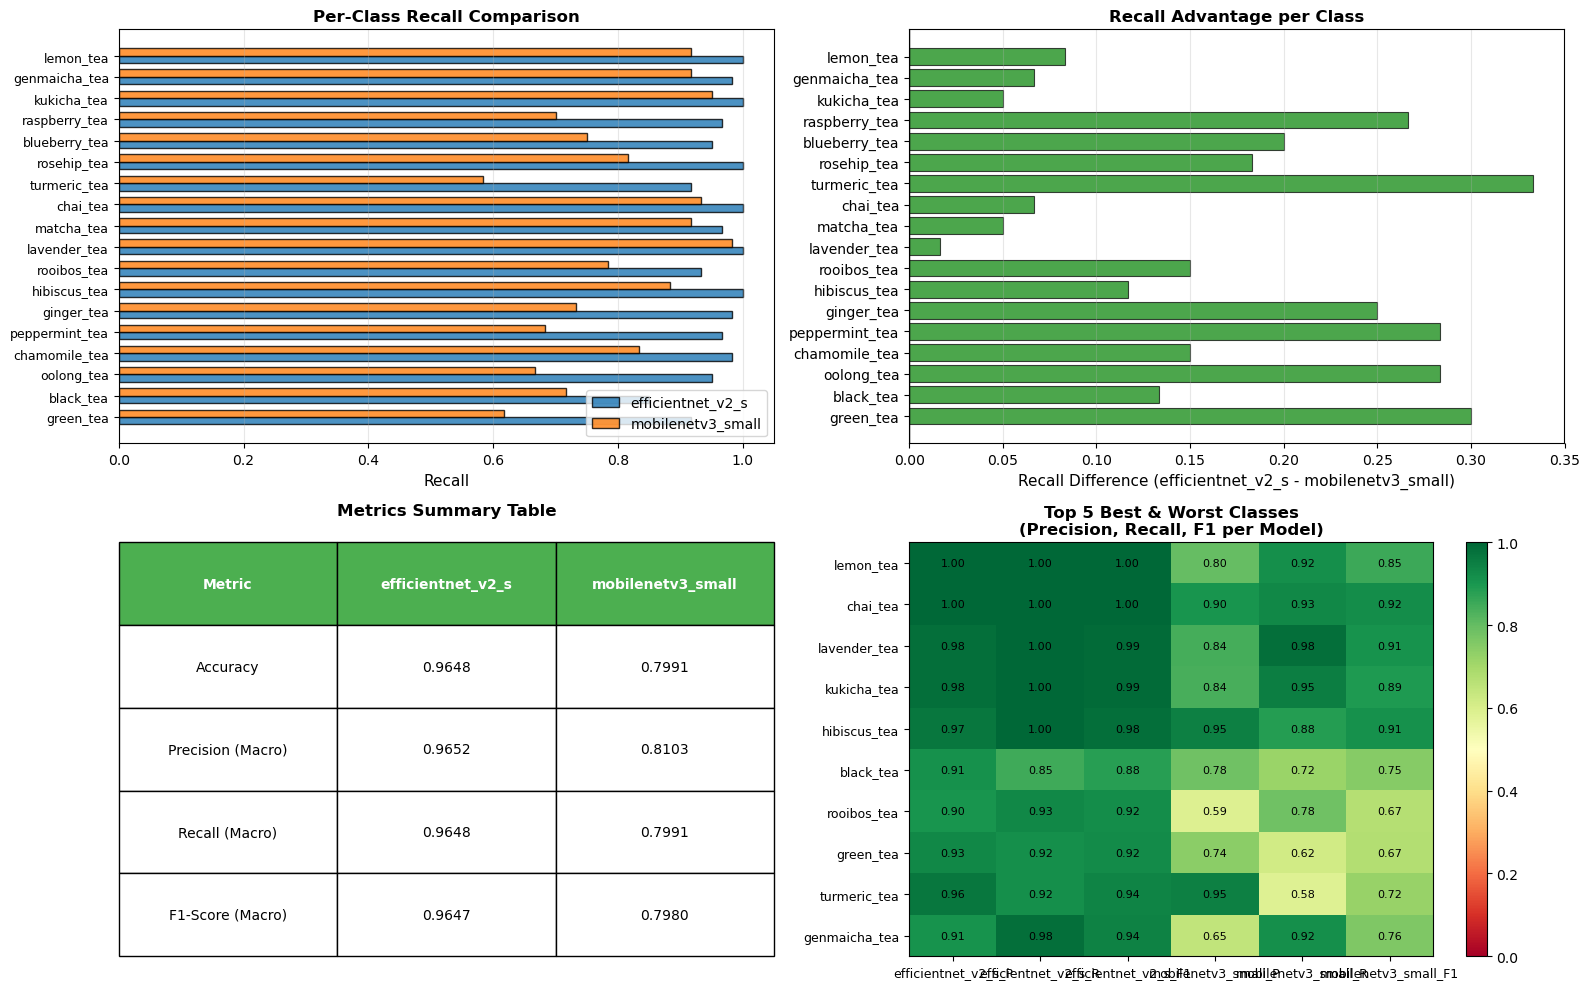

✓ Detailed per-class analysis displayed



In [62]:
# =========================
# 15. DETAILED PER-CLASS ANALYSIS & RECALL COMPARISON
# =========================
if len(model_results) == 2:
    model_list = list(model_results.keys())
    results1 = model_results[model_list[0]]
    results2 = model_results[model_list[1]]

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # 1. Per-Class Recall Comparison
    x_pos = np.arange(len(class_names))
    width = 0.35

    axes[0, 0].barh(
        np.arange(len(class_names)) - width / 2,
        results1["recall"],
        width,
        label=model_list[0],
        alpha=0.8,
        color="#1f77b4",
        edgecolor="black",
    )
    axes[0, 0].barh(
        np.arange(len(class_names)) + width / 2,
        results2["recall"],
        width,
        label=model_list[1],
        alpha=0.8,
        color="#ff7f0e",
        edgecolor="black",
    )
    axes[0, 0].set_yticks(np.arange(len(class_names)))
    axes[0, 0].set_yticklabels(class_names, fontsize=9)
    axes[0, 0].set_xlabel("Recall", fontsize=11)
    axes[0, 0].set_title("Per-Class Recall Comparison", fontsize=12, fontweight="bold")
    axes[0, 0].legend()
    axes[0, 0].grid(axis="x", alpha=0.3)

    # 2. Recall Difference (Model1 - Model2)
    recall_diff = results1["recall"] - results2["recall"]
    colors_diff = ["green" if d > 0 else "red" for d in recall_diff]

    axes[0, 1].barh(
        class_names,
        recall_diff,
        color=colors_diff,
        edgecolor="black",
        alpha=0.7,
        linewidth=0.8,
    )
    axes[0, 1].set_xlabel(
        f"Recall Difference ({model_list[0]} - {model_list[1]})", fontsize=11
    )
    axes[0, 1].set_title("Recall Advantage per Class", fontsize=12, fontweight="bold")
    axes[0, 1].axvline(x=0, color="black", linestyle="-", linewidth=1)
    axes[0, 1].grid(axis="x", alpha=0.3)

    # 3. Overall Metrics Summary
    metrics_summary = pd.DataFrame(
        {
            "Metric": [
                "Accuracy",
                "Precision (Macro)",
                "Recall (Macro)",
                "F1-Score (Macro)",
            ],
            model_list[0]: [
                f"{results1['accuracy']:.4f}",
                f"{results1['precision'].mean():.4f}",
                f"{results1['recall'].mean():.4f}",
                f"{results1['f1'].mean():.4f}",
            ],
            model_list[1]: [
                f"{results2['accuracy']:.4f}",
                f"{results2['precision'].mean():.4f}",
                f"{results2['recall'].mean():.4f}",
                f"{results2['f1'].mean():.4f}",
            ],
        }
    )

    # Plot as a table
    axes[1, 0].axis("off")
    table = axes[1, 0].table(
        cellText=metrics_summary.values,
        colLabels=metrics_summary.columns,
        cellLoc="center",
        loc="center",
        bbox=[0, 0, 1, 1],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)

    # Color header
    for i in range(len(metrics_summary.columns)):
        table[(0, i)].set_facecolor("#4CAF50")
        table[(0, i)].set_text_props(weight="bold", color="white")

    axes[1, 0].set_title(
        "Metrics Summary Table", fontsize=12, fontweight="bold", pad=20
    )

    # 4. Class-wise Performance Heatmap (visualizing model differences)
    performance_diff = np.column_stack(
        [
            results1["accuracy"] * np.ones(len(class_names)),  # dummy baseline
            results1["precision"],
            results1["recall"],
            results1["f1"],
            results2["precision"],
            results2["recall"],
            results2["f1"],
        ]
    )

    # Top classes by F1-score for Model 1
    top_classes_idx = np.argsort(results1["f1"])[-5:][::-1]
    worst_classes_idx = np.argsort(results1["f1"])[:5]

    best_worst_classes = np.concatenate([top_classes_idx, worst_classes_idx])
    best_worst_names = [class_names[i] for i in best_worst_classes]

    comparison_matrix = np.array(
        [
            [
                results1["precision"][i],
                results1["recall"][i],
                results1["f1"][i],
                results2["precision"][i],
                results2["recall"][i],
                results2["f1"][i],
            ]
            for i in best_worst_classes
        ]
    )

    im = axes[1, 1].imshow(
        comparison_matrix, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1
    )
    axes[1, 1].set_xticks(np.arange(6))
    axes[1, 1].set_yticks(np.arange(len(best_worst_names)))
    axes[1, 1].set_xticklabels(
        [
            f"{model_list[0]}_P",
            f"{model_list[0]}_R",
            f"{model_list[0]}_F1",
            f"{model_list[1]}_P",
            f"{model_list[1]}_R",
            f"{model_list[1]}_F1",
        ],
        fontsize=9,
    )
    axes[1, 1].set_yticklabels(best_worst_names, fontsize=9)
    axes[1, 1].set_title(
        "Top 5 Best & Worst Classes\n(Precision, Recall, F1 per Model)",
        fontsize=12,
        fontweight="bold",
    )
    plt.colorbar(im, ax=axes[1, 1])

    # Add text annotations
    for i in range(len(best_worst_names)):
        for j in range(6):
            text = axes[1, 1].text(
                j,
                i,
                f"{comparison_matrix[i, j]:.2f}",
                ha="center",
                va="center",
                color="black",
                fontsize=8,
            )

    plt.tight_layout()
    plt.show()

    print("✓ Detailed per-class analysis displayed\n")

In [63]:
# =========================
# 16. COMPREHENSIVE MODEL COMPARISON REPORT
# =========================
if len(model_results) == 2:
    model_list = list(model_results.keys())
    results1 = model_results[model_list[0]]
    results2 = model_results[model_list[1]]

    print("\n" + "=" * 100)
    print("COMPREHENSIVE MODEL COMPARISON REPORT - EFFICIENTNETV2S vs MOBILENETV3SMALL")
    print("=" * 100)

    # Overall Performance Summary
    print("\n📊 OVERALL PERFORMANCE SUMMARY:")
    print(f"{'='*100}")

    print(f"\n{model_list[0].upper()}:")
    print(f"  • Accuracy:          {results1['accuracy']:.4f}")
    print(
        f"  • Macro Precision:   {results1['precision'].mean():.4f} (min: {results1['precision'].min():.4f}, max: {results1['precision'].max():.4f})"
    )
    print(
        f"  • Macro Recall:      {results1['recall'].mean():.4f} (min: {results1['recall'].min():.4f}, max: {results1['recall'].max():.4f})"
    )
    print(
        f"  • Macro F1-Score:    {results1['f1'].mean():.4f} (min: {results1['f1'].min():.4f}, max: {results1['f1'].max():.4f})"
    )

    print(f"\n{model_list[1].upper()}:")
    print(f"  • Accuracy:          {results2['accuracy']:.4f}")
    print(
        f"  • Macro Precision:   {results2['precision'].mean():.4f} (min: {results2['precision'].min():.4f}, max: {results2['precision'].max():.4f})"
    )
    print(
        f"  • Macro Recall:      {results2['recall'].mean():.4f} (min: {results2['recall'].min():.4f}, max: {results2['recall'].max():.4f})"
    )
    print(
        f"  • Macro F1-Score:    {results2['f1'].mean():.4f} (min: {results2['f1'].min():.4f}, max: {results2['f1'].max():.4f})"
    )

    # Comparison
    print(f"\n📈 PERFORMANCE DIFFERENCE ({model_list[0]} vs {model_list[1]}):")
    print(f"{'='*100}")
    acc_diff = results1["accuracy"] - results2["accuracy"]
    prec_diff = results1["precision"].mean() - results2["precision"].mean()
    rec_diff = results1["recall"].mean() - results2["recall"].mean()
    f1_diff = results1["f1"].mean() - results2["f1"].mean()

    print(
        f"  • Accuracy Difference:    {acc_diff:+.4f} {'(Model1 better)' if acc_diff > 0 else '(Model2 better)'}"
    )
    print(
        f"  • Precision Difference:   {prec_diff:+.4f} {'(Model1 better)' if prec_diff > 0 else '(Model2 better)'}"
    )
    print(
        f"  • Recall Difference:      {rec_diff:+.4f} {'(Model1 better)' if rec_diff > 0 else '(Model2 better)'}"
    )
    print(
        f"  • F1-Score Difference:    {f1_diff:+.4f} {'(Model1 better)' if f1_diff > 0 else '(Model2 better)'}"
    )

    # Best Performing Classes
    print(f"\n🏆 BEST PERFORMING CLASSES (By F1-Score):")
    print(f"{'='*100}")

    top5_idx_m1 = np.argsort(results1["f1"])[-5:][::-1]
    top5_idx_m2 = np.argsort(results2["f1"])[-5:][::-1]

    print(f"\n{model_list[0].upper()}:")
    for i, idx in enumerate(top5_idx_m1, 1):
        print(
            f"  {i}. {class_names[idx]:20s} - F1: {results1['f1'][idx]:.4f} (Precision: {results1['precision'][idx]:.4f}, Recall: {results1['recall'][idx]:.4f})"
        )

    print(f"\n{model_list[1].upper()}:")
    for i, idx in enumerate(top5_idx_m2, 1):
        print(
            f"  {i}. {class_names[idx]:20s} - F1: {results2['f1'][idx]:.4f} (Precision: {results2['precision'][idx]:.4f}, Recall: {results2['recall'][idx]:.4f})"
        )

    # Worst Performing Classes
    print(f"\n⚠️  WORST PERFORMING CLASSES (By F1-Score):")
    print(f"{'='*100}")

    worst5_idx_m1 = np.argsort(results1["f1"])[:5]
    worst5_idx_m2 = np.argsort(results2["f1"])[:5]

    print(f"\n{model_list[0].upper()}:")
    for i, idx in enumerate(worst5_idx_m1, 1):
        print(
            f"  {i}. {class_names[idx]:20s} - F1: {results1['f1'][idx]:.4f} (Precision: {results1['precision'][idx]:.4f}, Recall: {results1['recall'][idx]:.4f})"
        )

    print(f"\n{model_list[1].upper()}:")
    for i, idx in enumerate(worst5_idx_m2, 1):
        print(
            f"  {i}. {class_names[idx]:20s} - F1: {results2['f1'][idx]:.4f} (Precision: {results2['precision'][idx]:.4f}, Recall: {results2['recall'][idx]:.4f})"
        )

    # Model Strengths & Weaknesses
    print(f"\n💪 MODEL STRENGTHS & WEAKNESSES:")
    print(f"{'='*100}")

    winner = model_list[0] if f1_diff > 0 else model_list[1]
    loser = model_list[1] if f1_diff > 0 else model_list[0]

    print(f"\n{winner.upper()} Strengths:")
    print(f"  • Overall better macro F1-score")
    print(f"  • Better performance on average across all classes")
    if acc_diff > 0:
        print(
            f"  • Higher overall accuracy ({results1['accuracy']:.4f} vs {results2['accuracy']:.4f})"
        )

    print(f"\n{loser.upper()} Strengths:")
    if f1_diff <= 0:
        print(
            f"  • Higher macro F1-score ({results2['f1'].mean():.4f} vs {results1['f1'].mean():.4f})"
        )
        print(f"  • Better performance on average across all classes")
    else:
        print(f"  • May be more efficient (lightweight model)")

    # Classes where each model performs best
    recall_diff = results1["recall"] - results2["recall"]
    best_for_m1 = np.argsort(recall_diff)[-3:][::-1]
    best_for_m2 = np.argsort(recall_diff)[:3]

    print(f"\n🎯 BEST RECALL BY MODEL:")
    print(f"  Classes where {model_list[0]} excels:")
    for idx in best_for_m1:
        print(
            f"    • {class_names[idx]:20s}: {results1['recall'][idx]:.4f} vs {results2['recall'][idx]:.4f}"
        )

    print(f"  Classes where {model_list[1]} excels:")
    for idx in best_for_m2:
        print(
            f"    • {class_names[idx]:20s}: {results2['recall'][idx]:.4f} vs {results1['recall'][idx]:.4f}"
        )

    print(f"\n{'='*100}\n")
    print("✓ Comprehensive comparison report complete\n")


COMPREHENSIVE MODEL COMPARISON REPORT - EFFICIENTNETV2S vs MOBILENETV3SMALL

📊 OVERALL PERFORMANCE SUMMARY:

EFFICIENTNET_V2_S:
  • Accuracy:          0.9648
  • Macro Precision:   0.9652 (min: 0.9032, max: 1.0000)
  • Macro Recall:      0.9648 (min: 0.8500, max: 1.0000)
  • Macro F1-Score:    0.9647 (min: 0.8793, max: 1.0000)

MOBILENETV3_SMALL:
  • Accuracy:          0.7991
  • Macro Precision:   0.8103 (min: 0.5875, max: 0.9464)
  • Macro Recall:      0.7991 (min: 0.5833, max: 0.9833)
  • Macro F1-Score:    0.7980 (min: 0.6714, max: 0.9180)

📈 PERFORMANCE DIFFERENCE (efficientnet_v2_s vs mobilenetv3_small):
  • Accuracy Difference:    +0.1657 (Model1 better)
  • Precision Difference:   +0.1549 (Model1 better)
  • Recall Difference:      +0.1657 (Model1 better)
  • F1-Score Difference:    +0.1667 (Model1 better)

🏆 BEST PERFORMING CLASSES (By F1-Score):

EFFICIENTNET_V2_S:
  1. lemon_tea            - F1: 1.0000 (Precision: 1.0000, Recall: 1.0000)
  2. chai_tea             - F1: 1.00

In [ ]:
# =========================
# 17. EXPORT COMPARISON RESULTS TO CSV
# =========================
if len(model_results) == 2:
    model_list = list(model_results.keys())
    results1 = model_results[model_list[0]]
    results2 = model_results[model_list[1]]

    # Export per-class metrics
    export_df = pd.DataFrame(
        {
            "Class": class_names,
            f"{model_list[0]}_Precision": results1["precision"],
            f"{model_list[0]}_Recall": results1["recall"],
            f"{model_list[0]}_F1": results1["f1"],
            f"{model_list[1]}_Precision": results2["precision"],
            f"{model_list[1]}_Recall": results2["recall"],
            f"{model_list[1]}_F1": results2["f1"],
        }
    )

    export_path = Path("model_comparison_results.csv")
    export_df.to_csv(export_path, index=False)
    print(f"✓ Per-class comparison exported to: {export_path}")

    # Export overall metrics
    overall_metrics_df = pd.DataFrame(
        {
            "Metric": [
                "Accuracy",
                "Macro Precision",
                "Macro Recall",
                "Macro F1-Score",
                "Min Precision",
                "Max Precision",
                "Min Recall",
                "Max Recall",
                "Min F1",
                "Max F1",
            ],
            model_list[0]: [
                results1["accuracy"],
                results1["precision"].mean(),
                results1["recall"].mean(),
                results1["f1"].mean(),
                results1["precision"].min(),
                results1["precision"].max(),
                results1["recall"].min(),
                results1["recall"].max(),
                results1["f1"].min(),
                results1["f1"].max(),
            ],
            model_list[1]: [
                results2["accuracy"],
                results2["precision"].mean(),
                results2["recall"].mean(),
                results2["f1"].mean(),
                results2["precision"].min(),
                results2["precision"].max(),
                results2["recall"].min(),
                results2["recall"].max(),
                results2["f1"].min(),
                results2["f1"].max(),
            ],
        }
    )

    overall_metrics_path = Path("model_comparison_overall_metrics.csv")
    overall_metrics_df.to_csv(overall_metrics_path, index=False)
    print(f"✓ Overall metrics comparison exported to: {overall_metrics_path}")

    print(f"\n📁 Exported files:")
    print(f"   1. {export_path}")
    print(f"   2. {overall_metrics_path}")
    print(f"\nYou can now use these CSV files for further analysis or reports.")

In [ ]:
# =========================
# 18. RADAR CHARTS - PRECISION, RECALL, ACCURACY, F1-SCORE
# =========================
if len(model_results) == 2:
    model_list = list(model_results.keys())
    results1 = model_results[model_list[0]]
    results2 = model_results[model_list[1]]

    from math import pi

    # Define categories for radar chart (overall metrics)
    categories = ["Precision", "Recall", "Accuracy", "F1-Score"]

    # Get values for both models
    values1 = [
        results1["precision"].mean(),
        results1["recall"].mean(),
        results1["accuracy"],
        results1["f1"].mean(),
    ]

    values2 = [
        results2["precision"].mean(),
        results2["recall"].mean(),
        results2["accuracy"],
        results2["f1"].mean(),
    ]

    # Number of variables
    N = len(categories)

    # Create figure with subplots (side-by-side radar charts)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw=dict(projection="polar"))

    # Calculate angle for each axis
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]  # Complete the circle

    # Model 1 Radar Chart
    values1_plot = values1 + values1[:1]
    ax1 = axes[0]
    ax1.plot(
        angles, values1_plot, "o-", linewidth=2, label=model_list[0], color="#1f77b4"
    )
    ax1.fill(angles, values1_plot, alpha=0.25, color="#1f77b4")
    ax1.set_xticks(angles[:-1])
    ax1.set_xticklabels(categories, size=10)
    ax1.set_ylim(0, 1)
    ax1.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax1.set_title(model_list[0].upper(), size=14, fontweight="bold", pad=20)
    ax1.grid(True, linestyle="--", alpha=0.7)
    ax1.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

    # Model 2 Radar Chart
    values2_plot = values2 + values2[:1]
    ax2 = axes[1]
    ax2.plot(
        angles, values2_plot, "o-", linewidth=2, label=model_list[1], color="#ff7f0e"
    )
    ax2.fill(angles, values2_plot, alpha=0.25, color="#ff7f0e")
    ax2.set_xticks(angles[:-1])
    ax2.set_xticklabels(categories, size=10)
    ax2.set_ylim(0, 1)
    ax2.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax2.set_title(model_list[1].upper(), size=14, fontweight="bold", pad=20)
    ax2.grid(True, linestyle="--", alpha=0.7)
    ax2.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

    plt.tight_layout()
    plt.savefig(Path("radar_charts_model_comparison.png"), dpi=300, bbox_inches="tight")
    plt.show()

    print("✓ Radar charts generated and saved\n")

In [ ]:
# =========================
# 19. PER-CLASS F1-SCORE LINE COMPARISON
# =========================
if len(model_results) == 2:
    model_list = list(model_results.keys())
    results1 = model_results[model_list[0]]
    results2 = model_results[model_list[1]]

    fig, ax = plt.subplots(figsize=(14, 7))

    x = np.arange(len(class_names))

    ax.plot(
        x,
        results1["f1"],
        "o-",
        linewidth=2.5,
        markersize=8,
        label=model_list[0],
        color="#1f77b4",
        alpha=0.8,
    )
    ax.plot(
        x,
        results2["f1"],
        "s-",
        linewidth=2.5,
        markersize=8,
        label=model_list[1],
        color="#ff7f0e",
        alpha=0.8,
    )

    ax.fill_between(x, results1["f1"], results2["f1"], alpha=0.2, color="gray")

    ax.set_xlabel("Tea Type", fontsize=12, fontweight="bold")
    ax.set_ylabel("F1-Score", fontsize=12, fontweight="bold")
    ax.set_title(
        "Per-Class F1-Score Comparison Across Models", fontsize=14, fontweight="bold"
    )
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_ylim([0, 1.05])
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(loc="best", fontsize=11)

    plt.tight_layout()
    plt.savefig(Path("per_class_f1_comparison.png"), dpi=300, bbox_inches="tight")
    plt.show()

    print("✓ Per-class F1-score comparison plotted\n")

In [ ]:
# =========================
# 20. TOP 5 & BOTTOM 5 PERFORMING CLASSES COMPARISON
# =========================
if len(model_results) == 2:
    model_list = list(model_results.keys())
    results1 = model_results[model_list[0]]
    results2 = model_results[model_list[1]]

    # Find top and bottom 5 classes by F1-score
    top5_indices = np.argsort(results1["f1"])[-5:][::-1]
    bottom5_indices = np.argsort(results1["f1"])[:5]

    top5_classes = [class_names[i] for i in top5_indices]
    bottom5_classes = [class_names[i] for i in bottom5_indices]

    top5_f1_m1 = results1["f1"][top5_indices]
    top5_f1_m2 = results2["f1"][top5_indices]

    bottom5_f1_m1 = results1["f1"][bottom5_indices]
    bottom5_f1_m2 = results2["f1"][bottom5_indices]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Top 5 Best Performing Classes
    x = np.arange(len(top5_classes))
    width = 0.35

    axes[0].bar(
        x - width / 2,
        top5_f1_m1,
        width,
        label=model_list[0],
        color="#1f77b4",
        alpha=0.8,
        edgecolor="black",
        linewidth=1.2,
    )
    axes[0].bar(
        x + width / 2,
        top5_f1_m2,
        width,
        label=model_list[1],
        color="#ff7f0e",
        alpha=0.8,
        edgecolor="black",
        linewidth=1.2,
    )

    axes[0].set_ylabel("F1-Score", fontsize=11, fontweight="bold")
    axes[0].set_title("Top 5 Best Performing Classes", fontsize=12, fontweight="bold")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(top5_classes, rotation=45, ha="right")
    axes[0].set_ylim([0, 1.05])
    axes[0].legend(fontsize=10)
    axes[0].grid(axis="y", alpha=0.3)

    # Add value labels on bars
    for i, (v1, v2) in enumerate(zip(top5_f1_m1, top5_f1_m2)):
        axes[0].text(
            i - width / 2, v1 + 0.02, f"{v1:.3f}", ha="center", va="bottom", fontsize=9
        )
        axes[0].text(
            i + width / 2, v2 + 0.02, f"{v2:.3f}", ha="center", va="bottom", fontsize=9
        )

    # Bottom 5 Worst Performing Classes
    x = np.arange(len(bottom5_classes))

    axes[1].bar(
        x - width / 2,
        bottom5_f1_m1,
        width,
        label=model_list[0],
        color="#1f77b4",
        alpha=0.8,
        edgecolor="black",
        linewidth=1.2,
    )
    axes[1].bar(
        x + width / 2,
        bottom5_f1_m2,
        width,
        label=model_list[1],
        color="#ff7f0e",
        alpha=0.8,
        edgecolor="black",
        linewidth=1.2,
    )

    axes[1].set_ylabel("F1-Score", fontsize=11, fontweight="bold")
    axes[1].set_title(
        "Bottom 5 Worst Performing Classes", fontsize=12, fontweight="bold"
    )
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(bottom5_classes, rotation=45, ha="right")
    axes[1].set_ylim([0, 1.05])
    axes[1].legend(fontsize=10)
    axes[1].grid(axis="y", alpha=0.3)

    # Add value labels on bars
    for i, (v1, v2) in enumerate(zip(bottom5_f1_m1, bottom5_f1_m2)):
        axes[1].text(
            i - width / 2, v1 + 0.02, f"{v1:.3f}", ha="center", va="bottom", fontsize=9
        )
        axes[1].text(
            i + width / 2, v2 + 0.02, f"{v2:.3f}", ha="center", va="bottom", fontsize=9
        )

    plt.tight_layout()
    plt.savefig(Path("top_bottom_classes_comparison.png"), dpi=300, bbox_inches="tight")
    plt.show()

    print("✓ Top 5 and Bottom 5 classes comparison generated\n")

In [ ]:
# =========================
# 21. DISTRIBUTION OF METRICS ACROSS ALL CLASSES (BOX PLOTS)
# =========================
if len(model_results) == 2:
    model_list = list(model_results.keys())
    results1 = model_results[model_list[0]]
    results2 = model_results[model_list[1]]

    # Prepare data for box plots
    metrics_data = {
        "Precision": [results1["precision"], results2["precision"]],
        "Recall": [results1["recall"], results2["recall"]],
        "F1-Score": [results1["f1"], results2["f1"]],
    }

    fig, axes = plt.subplots(1, 3, figsize=(16, 6))

    colors = ["#1f77b4", "#ff7f0e"]

    for idx, (metric_name, metric_data) in enumerate(metrics_data.items()):
        # Create box plot data
        box_data = metric_data

        bp = axes[idx].boxplot(
            box_data,
            labels=model_list,
            patch_artist=True,
            widths=0.6,
            notch=True,
            boxprops=dict(linewidth=1.5),
            medianprops=dict(color="red", linewidth=2),
            whiskerprops=dict(linewidth=1.5),
            capprops=dict(linewidth=1.5),
        )

        # Color the boxes
        for patch, color in zip(bp["boxes"], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        axes[idx].set_ylabel(f"{metric_name}", fontsize=11, fontweight="bold")
        axes[idx].set_title(
            f"Distribution of {metric_name} Across All Classes",
            fontsize=12,
            fontweight="bold",
        )
        axes[idx].set_ylim([0, 1.05])
        axes[idx].grid(axis="y", alpha=0.3, linestyle="--")

        # Add text with statistics
        stats_text = ""
        for i, (model_name, data) in enumerate(zip(model_list, box_data)):
            mean_val = np.mean(data)
            median_val = np.median(data)
            std_val = np.std(data)
            stats_text += f"\n{model_name}:\n  Mean: {mean_val:.3f}\n  Median: {median_val:.3f}\n  Std: {std_val:.3f}"

        axes[idx].text(
            0.98,
            0.02,
            stats_text,
            transform=axes[idx].transAxes,
            fontsize=9,
            verticalalignment="bottom",
            horizontalalignment="right",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
        )

    plt.tight_layout()
    plt.savefig(Path("metrics_distribution_boxplots.png"), dpi=300, bbox_inches="tight")
    plt.show()

    print("✓ Metrics distribution box plots generated\n")

In [ ]:
# =========================
# 22. SUMMARY - WHICH MODEL PERFORMS BEST & RECOMMENDATIONS
# =========================
if len(model_results) == 2:
    model_list = list(model_results.keys())
    results1 = model_results[model_list[0]]
    results2 = model_results[model_list[1]]

    print("\n" + "=" * 100)
    print("MODEL COMPARISON SUMMARY & RECOMMENDATIONS")
    print("=" * 100)

    # Calculate winner by different metrics
    acc_winner = (
        model_list[0] if results1["accuracy"] > results2["accuracy"] else model_list[1]
    )
    f1_winner = (
        model_list[0]
        if results1["f1"].mean() > results2["f1"].mean()
        else model_list[1]
    )
    prec_winner = (
        model_list[0]
        if results1["precision"].mean() > results2["precision"].mean()
        else model_list[1]
    )
    recall_winner = (
        model_list[0]
        if results1["recall"].mean() > results2["recall"].mean()
        else model_list[1]
    )

    print(f"\n🏆 METRIC WINNERS:")
    print(
        f"  • Overall Accuracy:        {acc_winner} ({max(results1['accuracy'], results2['accuracy']):.4f})"
    )
    print(
        f"  • Macro F1-Score:          {f1_winner} ({max(results1['f1'].mean(), results2['f1'].mean()):.4f})"
    )
    print(
        f"  • Macro Precision:         {prec_winner} ({max(results1['precision'].mean(), results2['precision'].mean()):.4f})"
    )
    print(
        f"  • Macro Recall:            {recall_winner} ({max(results1['recall'].mean(), results2['recall'].mean()):.4f})"
    )

    # Overall recommendation
    f1_diff = results1["f1"].mean() - results2["f1"].mean()

    print(f"\n💡 RECOMMENDATION:")
    if abs(f1_diff) < 0.01:
        print(f"  Both models perform comparably well.")
        print(
            f"  • Choose {model_list[0]} if you need HIGHER ACCURACY and can afford the computational cost"
        )
        print(
            f"  • Choose {model_list[1]} if you prioritize EFFICIENCY and deployment on mobile/edge devices"
        )
    elif f1_diff > 0:
        print(f"  {model_list[0].upper()} is the RECOMMENDED MODEL")
        print(
            f"  • Better overall F1-Score: {results1['f1'].mean():.4f} vs {results2['f1'].mean():.4f} (+{f1_diff:.4f})"
        )
        print(
            f"  • Better accuracy: {results1['accuracy']:.4f} vs {results2['accuracy']:.4f}"
        )
    else:
        print(f"  {model_list[1].upper()} is the RECOMMENDED MODEL")
        print(
            f"  • Better overall F1-Score: {results2['f1'].mean():.4f} vs {results1['f1'].mean():.4f} (+{abs(f1_diff):.4f})"
        )
        print(
            f"  • Better accuracy: {results2['accuracy']:.4f} vs {results1['accuracy']:.4f}"
        )

    print(f"\n📊 MODEL CHARACTERISTICS:")
    print(f"\n  {model_list[0].upper()}:")
    print(f"    • Input size: {results1['saved_state']['img_size']}")
    print(f"    • Strengths: Typically better for accuracy")
    print(f"    • Best for: High-accuracy requirements")
    print(f"    • Trade-off: Larger model size, more compute required")

    print(f"\n  {model_list[1].upper()}:")
    print(f"    • Input size: {results2['saved_state']['img_size']}")
    print(f"    • Strengths: Lightweight, faster inference")
    print(f"    • Best for: Mobile/edge deployment")
    print(f"    • Trade-off: Slightly lower accuracy")

    print(f"\n{'='*100}\n")
    print("✓ Summary complete\n")